## Image Cleaning - Open CV for CIFAR-10

The objective of this Python notebook is to compare 5 different Image Cleaning techniques on the Keras CIFAR-10 dataset, via OpenCV.

The methods used here are:
- No Processing
- MinMax Scaling
- Standard Scaler
- Quantile Transformer
- PCA

Note that RNNs are sequential models, so they're expected to do poorly on datasets like CIFAR-10, which consist of image data. However, we're retaining the RNN as the model here for comparison purposes with the MNIST notebook.

In [1]:
import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt

from keras.datasets import cifar10

In [2]:
(trainImg, trainLabel), (testImg, testLabel) = cifar10.load_data()

print(trainLabel.shape, testLabel.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(50000, 1) (10000, 1)


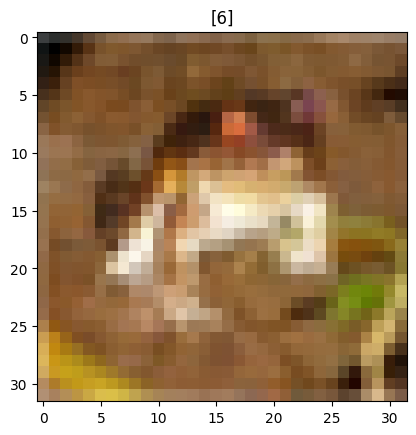

In [3]:
image = trainImg[0]
label = trainLabel[0]

plt.imshow(image)
plt.title(label)
plt.show()

## Image Cleaning Methods

In [4]:
# Method 1 - No Cleaning

def noClean(img):
  return img

In [5]:
# Method 2 - MinMax Scaling

def minMaxScaling(img):
  img = img.astype(np.float32)
  featureRange = (0, 1)
  return cv2.normalize(img, None, alpha=featureRange[0], beta=featureRange[1], norm_type=cv2.NORM_MINMAX)

In [6]:
# Method 3 - StandardScaler

def standardScaling(img):
  img = img.astype(np.float32)
  mean = np.mean(img)
  std = np.std(img)

  return (img - mean) / std

In [8]:
# Method 4 - Quantile Transformer

def quantileTransforming(img):
  imgTemp = img.astype(np.float32)

  flatImg = imgTemp.flatten()
  sortedImg = np.sort(flatImg)

  cdf = np.linspace(0, 1, len(sortedImg))

  transformedValues = np.interp(flatImg, sortedImg, cdf)
  return transformedValues.reshape(image.shape)

In [9]:
# Method 5 - PCA

def pcaMethod(img):
  imgTemp = img.astype(np.float32)
  flatImg = imgTemp.reshape(-1, image.shape[-1])

  mean = np.mean(flatImg, axis=0)
  centeredData = flatImg - mean

  covarianceMatrix = np.cov(centeredData, rowvar=False)
  eigenValues, eigenVectors = np.linalg.eigh(covarianceMatrix)

  sortedIndices = np.argsort(eigenValues)[::-1]
  eigenVectorsSorted = eigenVectors[:, sortedIndices]

  eigenVectorsFinal = eigenVectorsSorted[:, :50]

  pcaProjection = np.dot(centeredData, eigenVectorsFinal)

  reconstructedData = np.dot(pcaProjection, eigenVectorsFinal.T) + mean
  return reconstructedData.reshape(image.shape)

## Simple RNN Model

In [10]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam

def initRNN():
    model = Sequential([SimpleRNN(128, input_shape=(32, 96)), Dense(10, activation="softmax")])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [11]:
# Need to make labels Categorical for RNN
from keras.utils import to_categorical

trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical = to_categorical(testLabel, 10)

In [12]:
def comparisonModels(cleaningMethod):
  # Apply cleaning method to each image in train/test set
  trainImg2 = np.array([cleaningMethod(img) for img in trainImg])
  testImg2 = np.array([cleaningMethod(img) for img in testImg])

  # Normalising and re-shaping the images
  trainImg2 = (trainImg2/255.0)
  trainImg2 = trainImg2.reshape((trainImg2.shape[0], 32, 96))
  testImg2 = (testImg2/255.0)
  testImg2 = testImg2.reshape((testImg2.shape[0], 32, 96))

  # RNN Model
  model = initRNN()
  model.fit(trainImg2, trainLabelCategorical, epochs=5, batch_size=64)

  return model.evaluate(testImg2, testLabelCategorical)

## Evaluation

In [14]:
modelNoCleaning = comparisonModels(noClean)
modelMinMax = comparisonModels(minMaxScaling)
modelStandard = comparisonModels(standardScaling)
modelQuantile = comparisonModels(quantileTransforming)
modelPCA = comparisonModels(pcaMethod)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.2360 - loss: 2.0677
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.3098 - loss: 1.8851
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3434 - loss: 1.7931
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.3386 - loss: 1.8152
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3133 - loss: 1.8724
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3785 - loss: 1.7158
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.1771 - loss: 2.1590
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2288 - loss: 2.0713
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.2485 - loss: 2.0376
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2837 - loss: 1.9766
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3007 - loss: 1.9404
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.

In [15]:
listAllModels = [modelNoCleaning, modelMinMax, modelStandard, modelQuantile, modelPCA]
print(listAllModels)

[[1.719111680984497, 0.3781999945640564], [1.958648443222046, 0.29010000824928284], [1.7265114784240723, 0.38190001249313354], [1.888381838798523, 0.3172999918460846], [1.8436498641967773, 0.3174999952316284]]


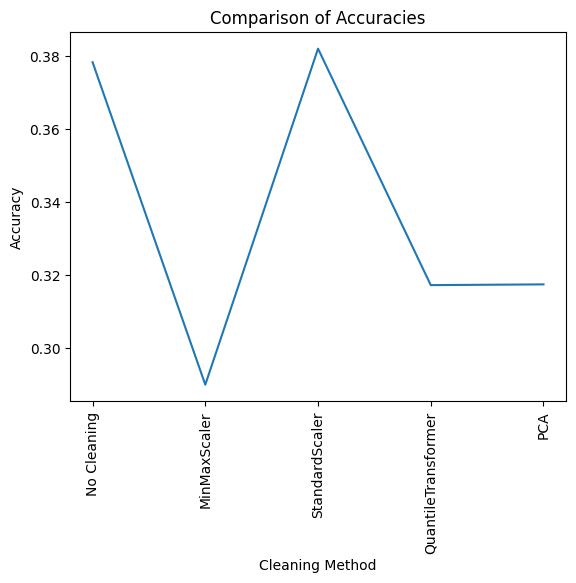

<Figure size 1200x1000 with 0 Axes>

In [16]:
plt.plot(["No Cleaning", "MinMaxScaler", "StandardScaler", "QuantileTransformer", "PCA"], [val[1] for val in listAllModels])
plt.title("Comparison of Accuracies")
plt.xlabel("Cleaning Method")
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.figure(figsize=(12, 10))
plt.show()



*   The worst performing pre-processing step is the MinMaxScaler, while the best one is the StandardScaler.
*   PCA and Quantile Transformation seem to perform similarly.
*   Overall, the performance for CIFAR-10 is worse than that of MNIST (image data, at the end of the day) - no cleaning is among the stronger performers here.



